# Punto de operación de un circuito con diodos

Un simulador de circuitos como **SPICE** tiene que resolver, antes de cualquier otra
cosa, un sistema de ecuaciones **no lineales**: las leyes de Kirchhoff son lineales,
pero la corriente de un diodo no lo es.

$$ I_D(V) = I_s \left( e^{V/V_t} - 1 \right) $$

El circuito de este notebook:

```
        R1           D            R2
  Vs ──/\/\/\── (1) ──▷|── (2) ──/\/\/\── GND
  5V            1 kΩ           1 kΩ
```

Aplicando corrientes en los nodos 1 y 2 queda un sistema de dos ecuaciones con dos
incógnitas, `V1` y `V2`. Lo resolvemos con Newton de dos maneras: con el paso
completo, y recortando el paso cuando el residuo no baja.

In [1]:
# Requisitos:  pip install numpy scipy matplotlib
# (En Google Colab ya vienen instalados.)
import numpy as np
import matplotlib.pyplot as plt

np.seterr(over="ignore")   # la exponencial del diodo va a desbordar a propósito

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

## El modelo del circuito

In [2]:
Vs, R1, R2 = 5.0, 1000.0, 1000.0     # fuente y resistencias
Is, Vt     = 1e-12, 0.025852         # diodo de silicio a 27 °C

def corriente_diodo(v):
    return Is * (np.exp(np.clip(v, -40, 80) / Vt) - 1.0)

def conductancia_diodo(v):           # dI/dV
    return (Is / Vt) * np.exp(np.clip(v, -40, 80) / Vt)

def F(V):
    """Corrientes netas en los nodos 1 y 2. En el punto de operación valen cero."""
    v1, v2 = V
    return np.array([(v1 - Vs) / R1 + corriente_diodo(v1 - v2),
                     -corriente_diodo(v1 - v2) + v2 / R2])

def J(V):
    """Matriz de conductancias (el Jacobiano de F)."""
    v1, v2 = V
    g = conductancia_diodo(v1 - v2)
    return np.array([[1/R1 + g,      -g],
                     [     -g,  g + 1/R2]])

## Newton, con y sin recorte del paso

In [3]:
def newton(V0, recortar, max_iter=60, tol=1e-12):
    V = np.array(V0, float)
    residuos = [np.linalg.norm(F(V))]

    for k in range(max_iter):
        Fv = F(V)
        n = np.linalg.norm(Fv)
        if n <= tol:
            return "converge", k, V, residuos
        if not np.isfinite(n) or n > 1e30:
            return "DESBORDA", k, V, residuos

        s = np.linalg.solve(J(V), -Fv)      # paso de Newton

        if recortar:
            lam = 1.0                        # se prueba el paso entero primero
            while lam > 1e-12:
                nt = np.linalg.norm(F(V + lam * s))
                if np.isfinite(nt) and nt <= (1 - 1e-4 * lam) * n:
                    break                    # el residuo bajó: aceptar
                lam *= 0.5                   # no bajó: medio paso
            V = V + lam * s
        else:
            V = V + s                        # paso completo, pase lo que pase

        residuos.append(np.linalg.norm(F(V)))

    return "sin converger", max_iter, V, residuos

## Resultado

In [4]:
resultados = {}
for etiqueta, recortar in [("paso completo", False), ("paso recortado", True)]:
    estado, k, V, res = newton([0.0, 0.0], recortar)
    resultados[etiqueta] = (estado, k, V, res)
    print(f"{etiqueta:15s} -> {estado:14s} en {k:2d} iteraciones")

print()
estado, k, V, res = resultados["paso recortado"]
print(f"Punto de operación:")
print(f"  V1 = {V[0]:.4f} V")
print(f"  V2 = {V[1]:.4f} V")
print(f"  caída en el diodo = {V[0]-V[1]:.4f} V")
print(f"  corriente         = {V[1]/R2*1000:.4f} mA")

paso completo   -> DESBORDA       en  1 iteraciones
paso recortado  -> converge       en  8 iteraciones

Punto de operación:
  V1 = 2.7782 V
  V2 = 2.2218 V
  caída en el diodo = 0.5564 V
  corriente         = 2.2218 mA


In [5]:
# Los tres primeros residuos de cada método
for etiqueta, (_, _, _, res) in resultados.items():
    print(f"{etiqueta:15s}", "  ".join(f"{r:.2e}" for r in res[:4]))

paso completo   5.00e-03  1.40e+72
paso recortado  5.00e-03  4.69e-03  4.49e-03  3.91e-03


## Qué pasó

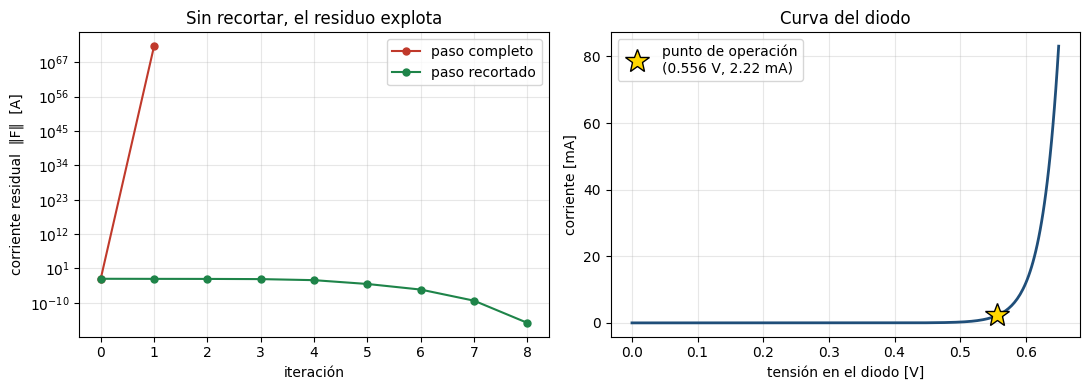

In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))

for etiqueta, color in [("paso completo", "#c0392b"), ("paso recortado", "#1e8449")]:
    r = np.array(resultados[etiqueta][3], float)
    r = np.where(np.isfinite(r) & (r > 0), r, np.nan)
    a1.semilogy(r, "o-", color=color, ms=5, label=etiqueta)
a1.set_xlabel("iteración")
a1.set_ylabel("corriente residual  ‖F‖  [A]")
a1.set_title("Sin recortar, el residuo explota")
a1.grid(alpha=.3); a1.legend()

v = np.linspace(0, 0.65, 300)
a2.plot(v, corriente_diodo(v) * 1000, color="#1f4e79", lw=2)
a2.plot(V[0]-V[1], V[1]/R2*1000, "*", color="gold", ms=18, mec="black",
        label=f"punto de operación\n({V[0]-V[1]:.3f} V, {V[1]/R2*1000:.2f} mA)")
a2.set_xlabel("tensión en el diodo [V]")
a2.set_ylabel("corriente [mA]")
a2.set_title("Curva del diodo")
a2.grid(alpha=.3); a2.legend()

plt.tight_layout(); plt.show()

El paso completo de Newton lleva el circuito a `V1 = 5 V`, `V2 = 0`, o sea **5 voltios
sobre el diodo**. Ahí `exp(5/0.0259)` es del orden de `10⁸⁴` y el residuo desborda en
la primera iteración.

Recortar el paso hasta que el residuo baje cuesta unas pocas evaluaciones más y
resuelve el circuito. Es exactamente lo que hace SPICE, y por eso funciona.